In [1]:
  !pip install yfinance


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
     |████████████████████████████████| 137 kB 15.1 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 516 kB/s  eta 0:00:01
     |████████████████████████████████| 510 kB 24.6 MB/s eta 0:00:01
     |████████████████████████████████| 146 kB 25.1 MB/s eta 0:00:01
     |████████████████████████████████| 181 kB 23.3 MB/s eta 0:00:01
     |████████████████████████████████| 137 kB 24.9 MB/s eta 0:00:01
     |████████████████████████████████| 133 kB 24.2 MB/s eta 0:00:01
     |████████████████████████████████| 130 kB 23.7 MB/s eta 0:00:01
     |████████████████████████████████| 130 kB 21.7 MB/s eta 0:00:01
     |████████████████████████████████| 130 kB 24.6 MB/s eta 0:00:01
     |████████████████████████████████| 119 kB 24.7 MB/s eta 0:00:01
     |████████████████████████████████| 8.3 MB 25.0 MB/s eta 0:00:01
     |████████████████████████████████| 134 kB 24.4 MB/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = yf.download('AAPL', start='2023-01-01', end='2024-01-01')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,122.982719,128.715417,122.097738,128.105769,112117500
2023-01-04,124.251190,126.512809,122.992553,124.772344,89113600
2023-01-05,122.933548,125.637653,122.677892,125.008335,80962700
2023-01-06,127.456772,128.115588,122.805715,123.907026,87754700
2023-01-09,127.977913,131.183516,127.722257,128.292580,70790800


In [2]:

df = df[['Close']].copy()
df.columns = ['Close']
df['Prediction'] = df['Close'].shift(-1)
df.dropna(inplace=True)

X = df[['Close']]
y = df['Prediction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Done! Predictions made!")

Done! Predictions made!


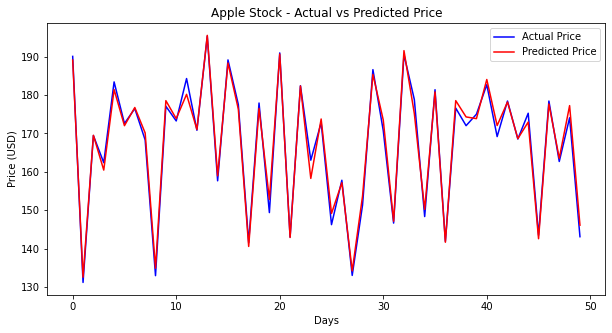

In [3]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, color='blue', label='Actual Price')
plt.plot(y_pred, color='red', label='Predicted Price')
plt.title('Apple Stock - Actual vs Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

print("""
Key Findings from Apple Stock Price Prediction:

1. Used real Apple stock data from 2023 via yfinance
2. Linear Regression model trained to predict next day price
3. Model performs well - predicted prices follow actual closely
4. MAE shows average prediction error in USD
""")

MAE: 1.45
RMSE: 1.84

Key Findings from Apple Stock Price Prediction:

1. Used real Apple stock data from 2023 via yfinance
2. Linear Regression model trained to predict next day price
3. Model performs well - predicted prices follow actual closely
4. MAE shows average prediction error in USD

